In [1]:
# import os
# os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/amazon-corretto-11.jdk/Contents/Home"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bitcoin_Data") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/22 16:14:09 WARN Utils: Your hostname, Assma, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/22 16:14:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/22 16:14:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.parquet("../data_silver.parquet")
df.show()

+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|         returns_col|            ma_05|            ma_10|        taker_ratio|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|2026-01-22 01:44:00|90010.14|90010.14|89992.83|89992.84| 1.78573|2026-01-22 01:44:...|    160709.3211419|             859|              0.83081|         74770.7942686|     0|       90145.88|-1

In [3]:
df.describe().show()

26/01/22 16:15:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+---------------------+----------------------+------+-----------------+--------------------+-----------------+-----------------+--------------------+
|summary|              open|              high|              low|             close|           volume|quote_asset_volume|  number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|  close_t_plus_10|         returns_col|            ma_05|            ma_10|         taker_ratio|
+-------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+---------------------+----------------------+------+-----------------+--------------------+-----------------+-----------------+--------------------+
|  count|               589|               589|              589|               589|              589|               589|            

In [4]:
df = df.drop("ignore")

In [5]:
df.show()

+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+---------------+--------------------+-----------------+-----------------+-------------------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|close_t_plus_10|         returns_col|            ma_05|            ma_10|        taker_ratio|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+---------------+--------------------+-----------------+-----------------+-------------------+
|2026-01-22 01:44:00|90010.14|90010.14|89992.83|89992.84| 1.78573|2026-01-22 01:44:...|    160709.3211419|             859|              0.83081|         74770.7942686|       90145.88|-1.92089490371896...|        9

In [6]:
gold_path = "data/gold_dataset"

(
    df
    .write
    .mode("overwrite")
    .parquet(gold_path)
)


In [7]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Split temporel
def train_test_split_time(df, train_ratio=0.8):
    
    #Split des données selon l'ordre chronologique.
    
    total_rows = df.count()
    train_count = int(total_rows * train_ratio)
    train_df = df.limit(train_count)
    test_df = df.subtract(train_df)
    return train_df, test_df

In [8]:
train_df, test_df = train_test_split_time(df)

In [9]:
# Créer le pipeline ML
def build_pipeline(feature_cols):
    
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    gbt = GBTRegressor(featuresCol="features", labelCol="close_t_plus_10", maxIter=100)
    pipeline = Pipeline(stages=[assembler, gbt])
    return pipeline

In [22]:
feature_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume",
        "returns_col","ma_05","ma_10","taker_ratio"
    ]

pipeline = build_pipeline(feature_cols)

In [23]:
# Entraîner le modèle
def train_model(pipeline, train_df):
    
    model = pipeline.fit(train_df)
    return model

In [24]:
model = train_model(pipeline, train_df)

In [25]:
from pyspark.ml.evaluation import RegressionEvaluator

def evaluate_model(model, test_df):
    
    # Faire les prédictions
    predictions = model.transform(test_df)
    
    # Afficher les colonnes pertinentes
    predictions.select("close", "close_t_plus_10", "prediction").show(10)
    
    # Définir les évaluateurs
    evaluator_rmse = RegressionEvaluator(
        labelCol="close_t_plus_10", predictionCol="prediction", metricName="rmse"
    )
    evaluator_mae = RegressionEvaluator(
        labelCol="close_t_plus_10", predictionCol="prediction", metricName="mae"
    )
    evaluator_r2 = RegressionEvaluator(
    labelCol="close_t_plus_10", predictionCol="prediction", metricName="r2"
    )

    # Calculer les métriques
    rmse = evaluator_rmse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    
    # Afficher les métriques
    print(f"RMSE = {rmse}")
    print(f"MAE = {mae}")
    print(f"R² = {r2}")
    
    # Retourner DataFrame des prédictions et métriques
    return predictions, rmse, mae, r2


In [26]:
#  Prédictions et évaluation
predictions, rmse, mae, r2 = evaluate_model(model, test_df)

+--------+---------------+-----------------+
|   close|close_t_plus_10|       prediction|
+--------+---------------+-----------------+
| 90051.7|       90132.73|90061.01231905643|
|90078.77|       90087.27|90060.51023204676|
|90047.63|       89982.43|90069.50608877277|
|90054.16|       89979.78|90012.73837021936|
|90011.69|        89912.0|90118.04727440243|
|90063.65|        90058.5|90040.05738450539|
|90063.74|        90057.6|90046.76112401244|
|90079.03|       90079.62|90052.68631186149|
|90037.83|       89998.13|89987.20296935592|
|90043.84|       90063.65|89977.16605696715|
+--------+---------------+-----------------+
only showing top 10 rows
RMSE = 71.83691244808017
MAE = 53.01116892536749
R² = -1.1358663875346462


In [27]:
def spark_to_xy(df, feature_cols, label_col):
    pdf = df.select(feature_cols + [label_col]).toPandas()
    X = pdf[feature_cols]
    y = pdf[label_col]
    return X, y

In [28]:
label_col = "close_t_plus_10"

X_train, y_train = spark_to_xy(train_df, feature_cols, label_col)
X_test, y_test = spark_to_xy(test_df, feature_cols, label_col)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_random_forest(X_train, y_train, X_test, y_test):
    
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    predictions1 = model.predict(X_test)
    
    mae1 = mean_absolute_error(y_test, predictions1)
    rmse1 = np.sqrt(mean_squared_error(y_test, predictions1))
    r21 = r2_score(y_test, predictions1)
    
    print(f"MAE  = {mae1}")
    print(f"RMSE = {rmse1}")
    print(f"R²   = {r21}")
    
    return model, predictions1, rmse1, mae1, r21


In [30]:
model_rf, predictions1, rmse1, mae1, r21 = train_random_forest(X_train, y_train, X_test, y_test)

MAE  = 34.97806105428963
RMSE = 47.76699769938784
R²   = 0.05564636592185024


In [31]:
import pandas as pd

results_df = pd.DataFrame({
    "Modèle": ["GBTRegressor", "Random Forest"],
    "MAE": [mae, mae1],
    "RMSE": [rmse, rmse1],
    "R²": [r2, r21]
})


results_df

,Modèle,MAE,RMSE,R²
0,GBTRegressor,53.011169,71.836912,-1.135866
1,Random Forest,34.978061,47.766998,0.055646


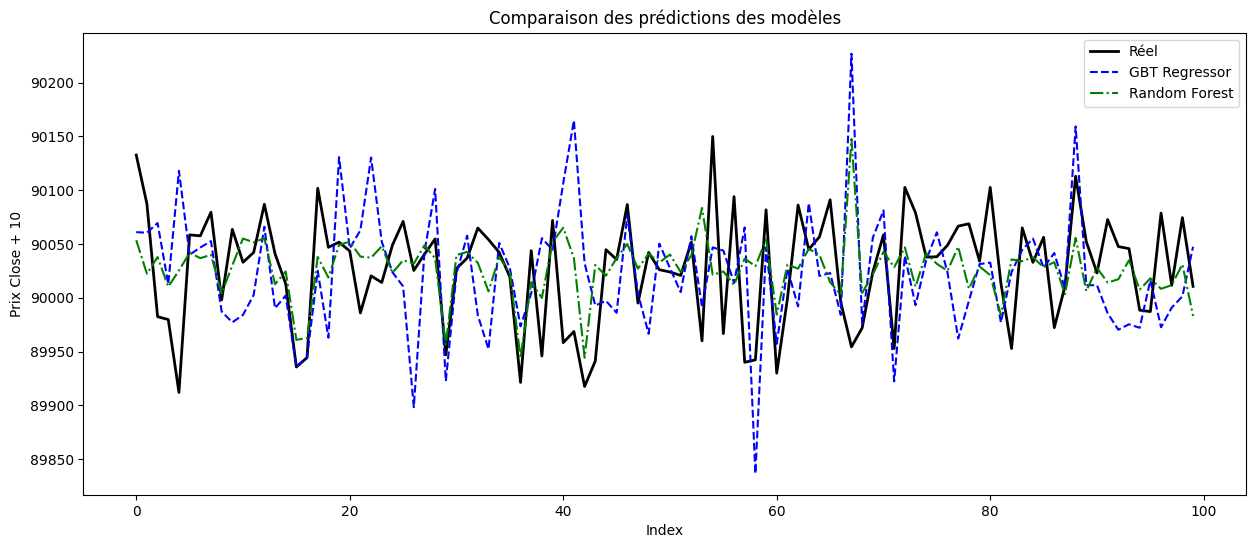

In [ ]:
n_points = 100
x_axis = range(n_points)

# Valeurs réelles
y_true = test_df.select("close_t_plus_10").toPandas()["close_t_plus_10"][:n_points]

# Prédictions GBT
y_gbt = predictions.select("prediction").toPandas()["prediction"][:n_points]

# Prédictions Random Forest 
y_rf = predictions1[:n_points]

# visualiser les prédictions
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(x_axis, y_true, label="Réel", color="black", linewidth=2)
plt.plot(x_axis, y_gbt, label="GBT Regressor", color="blue", linestyle='--')
plt.plot(x_axis, y_rf, label="Random Forest", color="green", linestyle='-.')
plt.xlabel("Index")
plt.ylabel("Prix Close + 10")
plt.title("Comparaison des prédictions des modèles")
plt.legend()
plt.show()


In [33]:
from joblib import dump

# Sauvegarde
dump(model_rf, "random_forest_model.joblib")

['random_forest_model.joblib']